## **PT-P2 Neural Network Training**

#**IMPORT AND LIBRARIES**

In [259]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

from collections import Counter
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Line-by-Line Explanation

This section explains the purpose of each line used for importing the required libraries and setting up reproducibility.

---

## Google Drive Connection

##### `from google.colab import drive` - This imports the Google Drive feature in Google Colab. I used this so I can access the files stored in my Google Drive.

##### `drive.mount('/content/drive')` - This connects my Google Drive to the Colab notebook. After mounting it, I can access my dataset using its file path inside the Drive folder.

---

## Data Processing Libraries

##### `import pandas as pd` - This imports the Pandas library and gives it the shortcut name `pd`. I use Pandas mainly for reading and handling the dataset.

##### `import numpy as np`- This imports NumPy as `np`. NumPy is useful for working with numerical values and arrays.

---

## TensorFlow

##### `import tensorflow as tf` - This imports TensorFlow. I use TensorFlow to build and train the neural network model.

---

## Neural Network Model and Layers

##### `from tensorflow.keras.models import Sequential` - This imports the `Sequential` model from Keras. It allows me to build the neural network layer by layer in order.

##### `from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout` - This imports the different layers used in the model. `Embedding` converts words into numerical vectors, `GlobalAveragePooling1D` summarizes the word vectors, `Dense` creates the fully connected layers, and `Dropout` helps reduce overfitting.

---

## Optimizers

##### `from tensorflow.keras.optimizers import Adam, SGD` - This imports the Adam and SGD optimizers. These optimizers control how the model updates its weights while learning from the training data.

---

## Early Stopping

##### `from tensorflow.keras.callbacks import EarlyStopping` - This imports `EarlyStopping`. I use this to automatically stop the training when the validation loss is no longer improving, which can help prevent overfitting.

---

## Dataset Splitting

##### `from sklearn.model_selection import train_test_split` - This imports `train_test_split` from Scikit-learn. I use it to divide the dataset into training and validation sets.

---

## Model Evaluation Metrics

##### `from sklearn.metrics import f1_score, accuracy_score`- This imports the F1-score and accuracy metrics. These are used to measure how well the trained model performs.

---

## Data Counting

##### `from collections import Counter`- This imports `Counter`, which is useful for counting how many times each item or class appears in the dataset.

---

## Data Visualization

##### `import matplotlib.pyplot as plt` - This imports Matplotlib's plotting feature as `plt`. I use it to create graphs such as the training and validation loss curves.

---

## Reproducibility

##### `np.random.seed(42)` - This sets the random seed used by NumPy to `42`. It helps make random operations produce the same results between runs.

##### `tf.random.set_seed(42)` - This sets TensorFlow's random seed to `42`. This also helps make the model training results more reproducible, although some small differences can still happen depending on the environment or hardware.

#**LOAD & PREPROCESS CSV DATA**

In [260]:
# ==========================================
# 1. LOAD & PREPROCESS CSV DATA
# ==========================================

CSV_FILEPATH = '/content/drive/MyDrive/NNTraining/Ong_Hotel_Dataset_550_Phrases.csv'
MAX_LEN = 20                  # Fixed sequence length (padded/truncated)
MAX_VOCAB_SIZE = 1000         # Vocabulary size limit

# Load CSV
df = pd.read_csv(CSV_FILEPATH)

# Basic Tokenizer & Vocabulary Builder
def build_vocab(texts, max_vocab_size):
    words = [word.lower() for text in texts for word in str(text).split()]
    word_counts = Counter(words)

    # Reserve index 0 for padding (<PAD>) and 1 for unknown tokens (<UNK>)
    most_common = word_counts.most_common(max_vocab_size - 2)

    vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab


def text_to_sequence(text, vocab, max_len):
    tokens = str(text).lower().split()
    seq = [vocab.get(token, 1) for token in tokens]

    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))   # Pad with 0
    else:
        seq = seq[:max_len]                 # Truncate

    return seq


# Build vocab and encode text
vocab = build_vocab(df['text phrase'].tolist(), MAX_VOCAB_SIZE)
encoded_texts = [text_to_sequence(txt, vocab, MAX_LEN) for txt in df['text phrase']]

X_data = np.array(encoded_texts)
y_data = np.array(df['label'].values)

num_classes = len(np.unique(y_data))

# Dataset Partitioning (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_data,
    y_data,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)


## Line-by-Line Explanation

This section explains how the CSV dataset is loaded, converted into numerical sequences, and divided into training, validation, and testing sets.

---

## Dataset File Path and Basic Settings

##### `CSV_FILEPATH = '/content/drive/MyDrive/NNTraining/Ong_Hotel_Dataset_550_Phrases.csv'` - This stores the location of my CSV dataset inside Google Drive. I use this file path so the program knows where to find and load the dataset.

##### `MAX_LEN = 20` - This sets the maximum sequence length to `20` words. Texts shorter than 20 words will be padded, while texts longer than 20 words will be shortened.

##### `MAX_VOCAB_SIZE = 1000` - This limits the vocabulary to a maximum of `1000` words. This helps control how many unique words the model needs to process.

---

## Load CSV Dataset

##### `df = pd.read_csv(CSV_FILEPATH)` - This reads the CSV file using Pandas and stores the dataset inside the variable `df`. This allows me to access and process the columns of the dataset.

---

## Vocabulary Builder Function

##### `def build_vocab(texts, max_vocab_size):` - This creates a function called `build_vocab`. The purpose of this function is to collect the words from the dataset and assign a numerical index to each word.

##### `words = [word.lower() for text in texts for word in str(text).split()]` - This goes through every text in the dataset, separates each text into individual words, converts the words into lowercase, and stores them in one list.

##### `word_counts = Counter(words)` - This counts how many times each word appears in the dataset. The word frequency is used to determine which words should be included in the vocabulary.

---

## Special Token Reservation

##### `most_common = word_counts.most_common(max_vocab_size - 2)` - This selects the most frequently used words in the dataset. Two spaces are reserved because index `0` and index `1` will be used for special tokens.

##### `vocab = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}` - This creates the vocabulary dictionary and assigns a unique numerical index to every selected word. The indexing starts at `2` because indices `0` and `1` are already reserved.

##### `vocab['<PAD>'] = 0` - This assigns index `0` to the `<PAD>` token. I use this token to fill the remaining positions when a text is shorter than the required sequence length.

##### `vocab['<UNK>'] = 1` - This assigns index `1` to the `<UNK>` token. This is used when the model encounters a word that is not included in the vocabulary.

##### `return vocab` - This returns the completed vocabulary dictionary so it can be used later for converting text into numerical sequences.

---

## Text-to-Sequence Function

##### `def text_to_sequence(text, vocab, max_len):` - This creates a function called `text_to_sequence`. Its purpose is to convert a text phrase into a sequence of numerical values based on the vocabulary.

##### `tokens = str(text).lower().split()` - This converts the text into lowercase and separates it into individual words or tokens.

##### `seq = [vocab.get(token, 1) for token in tokens]` - This replaces every token with its corresponding numerical index from the vocabulary. If a word is not found, it uses index `1`, which represents `<UNK>`.

---

## Padding and Truncation

##### `if len(seq) < max_len:` - This checks if the numerical sequence is shorter than the required maximum sequence length.

##### `seq += [0] * (max_len - len(seq))` - If the sequence is too short, this adds zeros at the end until it reaches the required length. The value `0` represents the `<PAD>` token.

##### `else:` - This runs when the sequence is already equal to or longer than the maximum allowed length.

##### `seq = seq[:max_len]` - If the sequence is too long, this keeps only the first `max_len` values and removes the remaining tokens.

##### `return seq` - This returns the final sequence after padding or truncation has been applied.

---

## Build the Vocabulary

##### `vocab = build_vocab(df['text phrase'].tolist(), MAX_VOCAB_SIZE)` - This creates the vocabulary using all the phrases from the `text phrase` column of the dataset. The vocabulary is limited according to `MAX_VOCAB_SIZE`.

---

## Encode the Text Phrases

##### `encoded_texts = [text_to_sequence(txt, vocab, MAX_LEN) for txt in df['text phrase']]` - This converts every text phrase in the dataset into a numerical sequence using the vocabulary and the fixed sequence length.

##### `X_data = np.array(encoded_texts)` - This converts all encoded text sequences into a NumPy array. This array will serve as the input data for the neural network.

##### `y_data = np.array(df['label'].values)` - This converts the values from the `label` column into a NumPy array. These labels represent the expected category of each text phrase.

---

## Number of Classes

##### `num_classes = len(np.unique(y_data))` - This identifies how many unique classes are available in the dataset. The value is later used to determine the number of outputs needed in the final classification layer.

---

## Dataset Partitioning

##### `X_train, X_temp, y_train, y_temp = train_test_split(` - This begins the first dataset split. It separates the input data and labels into a training set and a temporary set.

##### `X_data,` - This provides the complete encoded text data that will be divided.

##### `y_data,` - This provides the corresponding class labels that will be divided together with the encoded texts.

##### `test_size=0.30,` - This assigns `30%` of the full dataset to the temporary set, while the remaining `70%` is used for training.

##### `random_state=42` - This fixes the random split using the value `42`. This helps produce the same dataset partition when the code is run again.

##### `)` - This closes the first `train_test_split()` function.

---

## Validation and Test Set Split

##### `X_val, X_test, y_val, y_test = train_test_split(` - This begins the second dataset split. It divides the temporary set into validation and testing sets.

##### `X_temp,` - This uses the temporary input data created from the first dataset split.

##### `y_temp,` - This uses the temporary labels created from the first dataset split.

##### `test_size=0.50,` - This divides the temporary set equally. Half becomes the validation set and the other half becomes the test set.

##### `random_state=42` - This again uses the value `42` to make the split consistent and reproducible.

##### `)` - This closes the second `train_test_split()` function.

---

## Final Dataset Distribution

##### `70% Training Set` - This portion of the dataset is used by the neural network to learn the patterns between the text phrases and their corresponding labels.

##### `15% Validation Set` - This portion is used during training to check how well the model performs on data it is not directly learning from.

##### `15% Testing Set` - This portion is kept separate from training and validation and can be used later to evaluate the final performance of the trained model.

#**EXPERIMENT HYPERPARAMETER SETTINGS AND NEURAL NETWORK ARCHITECTURE**

In [261]:
# ==========================================
# 2. HYPERPARAMETER CONFIGURATION
# ==========================================

CONFIG = {
    "run_id": "EXP-22",
    "embed_dim": 32,
    "hidden_dim": 32,
    "learning_rate": 0.0008,
    "batch_size": 16,
    "epochs": 45,
    "optimizer_type": "Adam",
    "dropout_rate": 0.62
}


# ==========================================
# 3. KERAS SEQUENTIAL ARCHITECTURE
# ==========================================

model = Sequential()

# Embedding Layer (Pillar 1: Architecture)
model.add(Embedding(
    input_dim=len(vocab),
    output_dim=CONFIG["embed_dim"],
    input_length=MAX_LEN,
    mask_zero=True
))

# Global Average Pooling across token sequence dimension
model.add(GlobalAveragePooling1D())

# First Hidden Layer
model.add(Dense( CONFIG["hidden_dim"], activation='relu'))

# Regularization Layer (Pillar 3: Regularization)
model.add(Dropout(CONFIG["dropout_rate"]))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Line-by-Line Explanation

This section explains how the experiment settings are configured and how the neural network architecture is created using Keras Sequential.

---

## Hyperparameter Configuration

##### `CONFIG = {` - This creates a dictionary called `CONFIG`. I use this to store all the important hyperparameters of the experiment in one place so they are easier to change and track.

##### `"run_id": "EXP-22",` - This assigns the experiment ID as `EXP-22`. I use this to identify the specific training run when recording and comparing results.

##### `"embed_dim": 32,` - This sets the embedding dimension to `32`. This means each word in the vocabulary will be represented using a 32-dimensional numerical vector.

##### `"hidden_dim": 32,` - This sets the hidden layer to `32` neurons. These neurons help the model learn patterns from the processed text data.

##### `"learning_rate": 0.0008,` - This sets the learning rate to `0.0008`. The learning rate controls how much the model adjusts its weights during each training update.

##### `"batch_size": 16,` - This sets the batch size to `16`. This means the model processes 16 training samples before updating its weights.

##### `"epochs": 45,` - This sets the maximum number of training epochs to `45`. One epoch means the model has gone through the entire training dataset once.

##### `"optimizer_type": "Adam",` - This selects `Adam` as the optimizer for the experiment. Adam is responsible for adjusting the model weights while training.

##### `"dropout_rate": 0.62` - This sets the dropout rate to `0.62`. This means 62% of the neurons in the dropout layer are temporarily ignored during training to help reduce overfitting.

##### `}` - This closes the `CONFIG` dictionary after all the experiment settings have been defined.

---

## Keras Sequential Architecture

##### `model = Sequential()` - This creates a Sequential neural network model. I use Sequential because the layers of the model are arranged one after another in order.

---

## Embedding Layer

##### `model.add(Embedding(` - This adds an Embedding layer as the first layer of the neural network. Its purpose is to convert the numerical word indices into dense numerical vectors that the model can learn from.

##### `input_dim=len(vocab),` - This sets the number of possible input words based on the total size of the vocabulary that was created during preprocessing.

##### `output_dim=CONFIG["embed_dim"],` - This sets the size of each word embedding using the `embed_dim` value from the configuration. In this experiment, each word is represented using `32` values.

##### `input_length=MAX_LEN,` - This sets the expected input sequence length based on `MAX_LEN`. Since `MAX_LEN` is `20`, each input phrase contains exactly 20 positions after padding or truncation.

##### `mask_zero=True` - This tells the Embedding layer that the value `0` represents padding. This allows supported layers to ignore padded positions when processing the sequence.

##### `))` - This closes the Embedding layer and adds it to the Sequential model.

---

## Global Average Pooling Layer

##### `model.add(GlobalAveragePooling1D())` - This adds a Global Average Pooling layer. It calculates the average of the word embeddings across the sequence and converts the sequence into one fixed-size representation that can be passed to the next layer.

---

## Hidden Layer

##### `model.add(Dense(CONFIG["hidden_dim"], activation='relu'))` - This adds a fully connected hidden layer with `32` neurons based on the `hidden_dim` setting. The `ReLU` activation function helps the model learn more complex patterns from the text representations.

---

## Regularization Layer

##### `model.add(Dropout(CONFIG["dropout_rate"]))` - This adds a Dropout layer using the configured dropout rate of `0.62`. During training, some neurons are randomly ignored to prevent the model from depending too much on specific features and to help reduce overfitting.

---

## Output Layer

##### `model.add(Dense(num_classes, activation='softmax'))` - This adds the final output layer of the model. The number of neurons is based on `num_classes`, so there is one output for each classification category.

##### `activation='softmax'` - The Softmax activation converts the output values into probabilities for each class. The class with the highest probability becomes the model's predicted category.

#**MODEL TRAINING & PERFORMANCE EVALUATION**

In [262]:
# ==========================================
# 4. OPTIMIZER & COMPILATION
# ==========================================

if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

# Configure loss function, optimizer engine, and evaluation metrics
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model.summary()

# ==========================================
# 5. THE OPERATIONAL LOOP (FIT & EVALUATE)
# ==========================================

print(f"--- Starting Training Run: {CONFIG['run_id']} ---")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

# Compute final validation predictions for F1-Score calculation
val_preds_probs = model.predict(X_val)
val_preds = np.argmax(val_preds_probs, axis=1)

val_f1 = f1_score(y_val, val_preds, average='weighted')
val_loss = history.history['val_loss'][-1]

# Final Log Output summary for Excel logging
print(f"\n=== EXP LOG ENTRY ===")
print(
    f"ID: {CONFIG['run_id']} | "
    f"LR: {CONFIG['learning_rate']} | "
    f"Hidden: {CONFIG['hidden_dim']} | "
    f"Dropout: {CONFIG['dropout_rate']} | "
    f"Final Val Loss: {val_loss:.4f} | "
    f"Final Val F1: {val_f1:.4f}"
)

Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_50 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_50     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- Starting Training Run: EXP-22 ---
Epoch 1/45
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3948 - loss: 1.0961 - val_accuracy: 0.8415 - val_loss: 1.0885
Epoch 2/45
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7117 - loss: 1.0781 - val_accuracy: 0.8415 - val_loss: 1.0683
Epoch 3/45
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7429 - loss: 1.0482 - val_accuracy: 0.7683 - val_loss: 1.0274
Epoch 4/45
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8208 - loss: 0.9813 - val_accuracy: 0.8537 - val_loss: 0.9526
Epoch 5/45
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8208 - loss: 0.8989 - val_accuracy: 0.8659 - val_loss: 0.8472
Epoch 6/45
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8727 - loss: 0.7749 - val_accuracy: 0.9024 - val_loss: 0.7193
Epoch 7/45
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9065 - loss: 0.6388 - val_accuracy: 0.9390 - val_loss: 0.5966
Epoch 8/45
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9195 - loss: 0.

## Line-by-Line Explanation

This section explains how the optimizer is selected, how the model is compiled, how Early Stopping is configured, and how the model is trained and evaluated using the validation data.

---

## Optimizer Selection

##### `if CONFIG["optimizer_type"] == "Adam":` - This checks the optimizer type stored inside the `CONFIG` dictionary. If the selected optimizer is `Adam`, the program will use the Adam optimizer.

##### `opt = Adam(learning_rate=CONFIG["learning_rate"])` - This creates the Adam optimizer and uses the learning rate stored in the configuration. In this experiment, the learning rate controls how much the model adjusts its weights during training.

##### `else:` - This runs when the selected optimizer is not `Adam`.

##### `opt = SGD(learning_rate=CONFIG["learning_rate"])` - This creates the SGD optimizer using the same configured learning rate. This gives me another optimizer option that I can use for different experiment runs.

---

## Model Compilation

##### `model.compile(` - This starts the compilation of the neural network model. Compiling the model prepares it for training by defining the loss function, optimizer, and evaluation metrics.

##### `loss='sparse_categorical_crossentropy',` - This sets `sparse_categorical_crossentropy` as the loss function. I use this because the target labels are represented as integer class values instead of one-hot encoded values.

##### `optimizer=opt,` - This tells the model to use the optimizer stored in the variable `opt`. The optimizer may be Adam or SGD depending on the experiment configuration.

##### `metrics=['accuracy']` - This sets accuracy as one of the evaluation metrics. Accuracy shows the percentage of predictions that the model classified correctly.

##### `)` - This closes the `model.compile()` function and completes the compilation setup.

---

## Early Stopping

##### `early_stop = EarlyStopping(` - This creates an Early Stopping callback. I use this to stop the training automatically when the validation performance is no longer improving.

##### `monitor='val_loss',` - This tells Early Stopping to monitor the validation loss after every epoch.

##### `patience=2,` - This allows the model to continue training for two more epochs even if the validation loss does not improve. If there is still no improvement after those two epochs, the training will stop.

##### `restore_best_weights=True` - This tells the model to restore the weights from the epoch where the validation loss performed best instead of keeping the weights from the final epoch.

##### `)` - This closes the Early Stopping configuration.

---

## Model Summary

##### `model.summary()` - This displays the structure of the neural network, including the layers, output shapes, and number of trainable parameters. I use this to check whether the model architecture was created correctly.

---

## Training Run Identification

##### `print(f"--- Starting Training Run: {CONFIG['run_id']} ---")` - This prints the experiment ID before training starts. It helps me identify which experiment configuration is currently being executed.

---

## Model Training

##### `history = model.fit(` - This starts the training process and stores the training results inside the variable `history`. The history contains values such as training loss, validation loss, and accuracy for each epoch.

##### `X_train,` - This provides the training input data that the model will use to learn patterns.

##### `y_train,` - This provides the correct class labels for the training data.

##### `validation_data=(X_val, y_val),` - This provides the validation dataset. The model uses this data to measure its performance after each training epoch without directly learning from it.

##### `epochs=CONFIG["epochs"],` - This sets the maximum number of training epochs using the value stored in the configuration.

##### `batch_size=CONFIG["batch_size"],` - This sets how many training samples are processed before the model updates its weights.

##### `callbacks=[early_stop],` - This applies the Early Stopping callback during training. It allows the training process to stop early if the validation loss stops improving.

##### `verbose=1` - This controls how much training information is displayed. A value of `1` shows the progress of every epoch, including the loss and accuracy values.

##### `)` - This closes the `model.fit()` function and completes the training setup.

---

## Validation Predictions

##### `val_preds_probs = model.predict(X_val)` - This uses the trained model to generate prediction probabilities for every sample in the validation set.

##### `val_preds = np.argmax(val_preds_probs, axis=1)` - This finds the class with the highest predicted probability for each validation sample. The result becomes the final predicted class label.

---

## F1-Score Calculation

##### `val_f1 = f1_score(y_val, val_preds, average='weighted')` - This calculates the weighted F1-score using the actual validation labels and the predicted labels. The weighted average considers the number of samples in each class when calculating the final F1-score.

---

## Validation Loss

##### `val_loss = history.history['val_loss'][-1]` - This gets the last recorded validation loss from the training history. The `[-1]` selects the final value stored in the validation loss list.

---

## Experiment Log Output

##### `print(f"\n=== EXP LOG ENTRY ===")` - This prints a heading for the experiment result summary. The `\n` creates a new line before the heading to make the output easier to read.

##### `print(` - This starts the print statement that combines the important experiment settings and validation results into one output.

##### `f"ID: {CONFIG['run_id']} | "` - This prints the experiment ID so I can identify which training run produced the results.

##### `f"LR: {CONFIG['learning_rate']} | "` - This prints the learning rate used in the experiment.

##### `f"Hidden: {CONFIG['hidden_dim']} | "` - This prints the number of neurons used in the hidden layer.

##### `f"Dropout: {CONFIG['dropout_rate']} | "` - This prints the dropout rate used for regularization.

##### `f"Final Val Loss: {val_loss:.4f} | "` - This prints the validation loss and rounds the value to four decimal places.

##### `f"Final Val F1: {val_f1:.4f}"` - This prints the weighted validation F1-score and rounds the value to four decimal places.

##### `)` - This closes the print statement and completes the experiment log output.

#**TRAINING & VALIDATION LOSS CURVES**

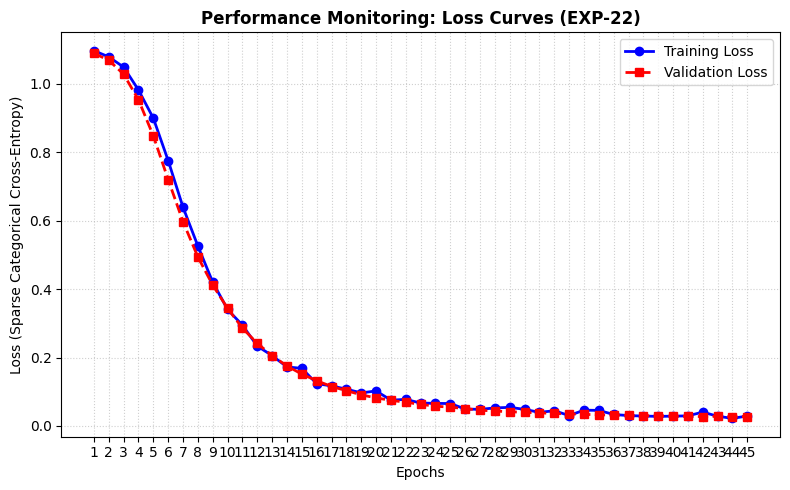

In [263]:
# ==========================================
# 6. GENERATE LOSS CURVES CHART
# ==========================================

train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)


plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    label='Training Loss',
    color='blue',
    linewidth=2,
    marker='o'
)

plt.plot(
    epochs_range,
    val_losses,
    label='Validation Loss',
    color='red',
    linewidth=2,
    linestyle='--',
    marker='s'
)

plt.title(
    f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

## Line-by-Line Explanation

This section explains how the training and validation loss values are collected from the model history and displayed as a loss curve chart to monitor the model's performance across each epoch.

---

## Retrieve Loss Values

##### `train_losses = history.history['loss']` - This gets all the training loss values recorded during the training process. Each value represents the training loss for a specific epoch.

##### `val_losses = history.history['val_loss']` - This gets all the validation loss values recorded during training. I use these values to check how well the model performs on validation data after each epoch.

##### `epochs_range = range(1, len(train_losses) + 1)` - This creates a sequence of epoch numbers starting from `1` up to the total number of epochs that were actually completed. This is useful because Early Stopping may stop the training before reaching the maximum number of configured epochs.

---

## Create the Figure

##### `plt.figure(figsize=(8, 5))` - This creates a new figure for the loss curve chart. The figure size is set to `8` inches wide and `5` inches high to make the graph easier to read.

---

## Plot Training Loss

##### `plt.plot(` - This starts the command for plotting the training loss values on the graph.

##### `epochs_range,` - This uses the epoch numbers as the values displayed on the horizontal or X-axis.

##### `train_losses,` - This uses the recorded training loss values as the values displayed on the vertical or Y-axis.

##### `label='Training Loss',` - This gives the training loss line the label `Training Loss`. This label will later appear in the graph legend.

##### `color='blue',` - This sets the training loss line to blue so it can be easily identified from the validation loss.

##### `linewidth=2,` - This sets the thickness of the training loss line to `2` to make it more visible.

##### `marker='o'` - This places a circular marker on every training loss value so I can clearly see the result of each epoch.

##### `)` - This closes the plotting command for the training loss curve.

---

## Plot Validation Loss

##### `plt.plot(` - This starts another plotting command, this time for the validation loss values.

##### `epochs_range,` - This uses the same epoch numbers on the X-axis so the training and validation loss can be directly compared.

##### `val_losses,` - This uses the recorded validation loss values as the values on the Y-axis.

##### `label='Validation Loss',` - This gives the validation loss line the label `Validation Loss`, which will appear in the graph legend.

##### `color='red',` - This sets the validation loss line to red so it can be distinguished from the blue training loss line.

##### `linewidth=2,` - This sets the thickness of the validation loss line to `2`.

##### `linestyle='--',` - This makes the validation loss line dashed. This gives another visual difference between the training and validation loss curves.

##### `marker='s'` - This places a square marker on every validation loss value to show the result recorded at each epoch.

##### `)` - This closes the plotting command for the validation loss curve.

---

## Chart Title

##### `plt.title(` - This starts the configuration for the title displayed at the top of the graph.

##### `f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})',` - This creates the chart title and automatically includes the current experiment ID. This helps me identify which experiment produced the displayed loss curves.

##### `fontsize=12,` - This sets the font size of the chart title to `12`.

##### `fontweight='bold'` - This makes the chart title bold so it stands out from the other labels.

##### `)` - This closes the chart title configuration.

---

## Axis Labels

##### `plt.xlabel('Epochs', fontsize=10)` - This labels the horizontal or X-axis as `Epochs`. It represents each complete training cycle performed by the model.

##### `plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)` - This labels the vertical or Y-axis with the loss measurement used by the model. It shows how much error the model produced during training and validation.

---

## Epoch Labels

##### `plt.xticks(epochs_range)` - This sets the X-axis tick marks to show the individual epoch numbers. This makes it easier to identify the loss value at each training epoch.

---

## Grid Lines

##### `plt.grid(True, linestyle=':', alpha=0.6)` - This adds grid lines to the chart to make the values easier to follow. The grid uses dotted lines and an opacity of `0.6` so it does not distract from the loss curves.

---

## Chart Legend

##### `plt.legend(loc='upper right')` - This displays the chart legend in the upper-right corner. The legend helps identify which line represents the training loss and which line represents the validation loss.

---

## Chart Layout

##### `plt.tight_layout()` - This automatically adjusts the spacing of the graph elements so the title, labels, and other parts of the chart fit properly without overlapping.

---

## Display the Loss Curve

##### `plt.show()` - This displays the completed loss curve chart in the Google Colab output. I use this graph to visually compare the training and validation loss and observe whether the model is learning properly or showing possible signs of overfitting.